In [1]:
import pandas as pd
import os
import re

# ==========================================
# CELL 1: ĐỌC VÀ LÀM SẠCH DỮ LIỆU
# ==========================================
# Tự động nhận diện đường dẫn
base_dir = 'data/processed/archive'
if not os.path.exists(base_dir):
    # Thêm chữ 'r' phía trước chuỗi để sửa lỗi escape character của đường dẫn trên Windows
    base_dir = r'E:\Project\data\processed\archive'

csv_path = os.path.join(base_dir, 'cheating_dataset.csv')
df = pd.read_csv(csv_path)

def doc_noi_dung(ten_file):
    if not str(ten_file).endswith('.py'):
        ten_file = str(ten_file) + '.py'
    duong_dan = os.path.join(base_dir, ten_file)
    try:
        with open(duong_dan, 'r', encoding='utf-8') as f:
            return f.read()
    except FileNotFoundError:
        return ""

def lam_sach_code(code_text):
    code_text = re.sub(r'#.*', '', code_text)
    code_text = re.sub(r'(\'\'\'(.*?)\'\'\'|\"\"\"(.*?)\"\"\")', '', code_text, flags=re.DOTALL)
    code_text = re.sub(r'\s+', ' ', code_text).strip()
    return code_text

# Đã sử dụng đúng tên cột File_1 và File_2 từ file CSV
df['code_1_sach'] = df['File_1'].apply(lambda x: lam_sach_code(doc_noi_dung(x)))
df['code_2_sach'] = df['File_2'].apply(lambda x: lam_sach_code(doc_noi_dung(x)))
print("-> BƯỚC 1 XONG: Đã load và làm sạch mã nguồn.") # Sửa &gt; thành >
# ==========================================
# CELL 1.5: KIỂM TRA THÔNG TIN DỮ LIỆU
# ==========================================
print(f"Tổng số dòng (mẫu): {len(df)}")
print(f"Tổng số cột (đặc trưng): {df.shape[1]}")
print("-" * 30)

print("Các cột hiện có:")
print(df.columns.tolist())
print("-" * 30)

# Xem thử 5 dòng đầu
display(df.head())

# ==========================================
# CELL 2: CHẠY BASELINE (JACCARD SIMILARITY)
# ==========================================
def jaccard_similarity(code1, code2, n=3):
    ngrams1 = set([code1[i:i+n] for i in range(len(code1)-n+1)])
    ngrams2 = set([code2[i:i+n] for i in range(len(code2)-n+1)])
    intersection = ngrams1.intersection(ngrams2)
    union = ngrams1.union(ngrams2)
    if len(union) == 0: return 0.0
    return len(intersection) / len(union)

# Tính điểm tương đồng
df['similarity_score'] = df.apply(lambda row: jaccard_similarity(row['code_1_sach'], row['code_2_sach']), axis=1)

# Máy dự đoán (Ngưỡng 65%)
df['du_doan'] = (df['similarity_score'] > 0.65).astype(int) # Sửa &gt; thành >
print("-> BƯỚC 2 XONG: Đã tính điểm tương đồng. Bạn hãy chạy Cell tiếp theo để vẽ biểu đồ nhé!") # Sửa &gt; thành >


-> BƯỚC 1 XONG: Đã load và làm sạch mã nguồn.
Tổng số dòng (mẫu): 293
Tổng số cột (đặc trưng): 5
------------------------------
Các cột hiện có:
['File_1', 'File_2', 'Label', 'code_1_sach', 'code_2_sach']
------------------------------


,File_1,File_2,Label,code_1_sach,code_2_sach
0,submission1.py,submission2.py,1,"def add(a, b): return a + b","def add(a, b): return a + b"
1,submission1.py,submission3.py,0,"def add(a, b): return a + b","def subtract(a, b): return a - b"
2,submission1.py,submission4.py,1,"def add(a, b): return a + b","def add(a, b): result = a + b return result"
3,submission1.py,submission5.py,0,"def add(a, b): return a + b","def multiply(a, b): return a * b"
4,submission2.py,submission3.py,0,"def add(a, b): return a + b","def subtract(a, b): return a - b"


-> BƯỚC 2 XONG: Đã tính điểm tương đồng. Bạn hãy chạy Cell tiếp theo để vẽ biểu đồ nhé!


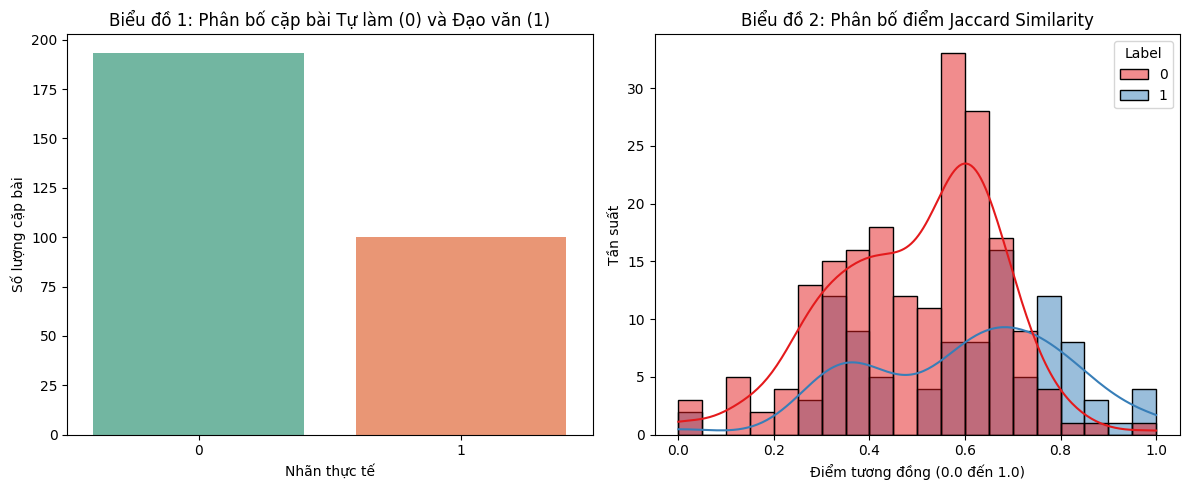


--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH BASELINE ---
              precision    recall  f1-score   support

           0       0.75      0.83      0.79       193
           1       0.59      0.48      0.53       100

    accuracy                           0.71       293
   macro avg       0.67      0.65      0.66       293
weighted avg       0.70      0.71      0.70       293

Số lượng cột trong dữ liệu là: 7
Tổng số dòng (mẫu): 293
Tổng số cột (đặc trưng): 7
------------------------------
Các cột hiện có:
['File_1', 'File_2', 'Label', 'code_1_sach', 'code_2_sach', 'similarity_score', 'du_doan']
------------------------------


,File_1,File_2,Label,code_1_sach,code_2_sach,similarity_score,du_doan
0,submission1.py,submission2.py,1,"def add(a, b): return a + b","def add(a, b): return a + b",1.000000,1
1,submission1.py,submission3.py,0,"def add(a, b): return a + b","def subtract(a, b): return a - b",0.447368,0
2,submission1.py,submission4.py,1,"def add(a, b): return a + b","def add(a, b): result = a + b return result",0.666667,1
3,submission1.py,submission5.py,0,"def add(a, b): return a + b","def multiply(a, b): return a * b",0.447368,0
4,submission2.py,submission3.py,0,"def add(a, b): return a + b","def subtract(a, b): return a - b",0.447368,0


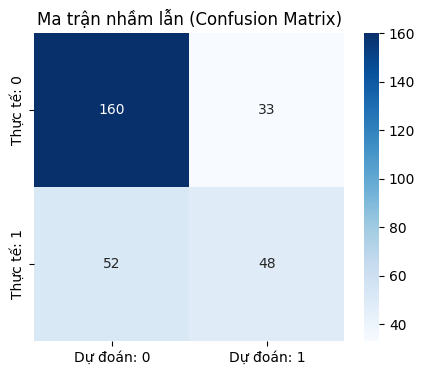

In [2]:
# CELL 3: VẼ BIỂU ĐỒ VÀ ĐÁNH GIÁ KẾT QUẢ
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

plt.figure(figsize=(12, 5))

# --- Biểu đồ 1: Phân bố nhãn (Label) ---
plt.subplot(1, 2, 1)
# Thêm hue='Label' và legend=False để tránh cảnh báo FutureWarning của Seaborn
sns.countplot(data=df, x='Label', hue='Label', palette='Set2', legend=False)
plt.title('Biểu đồ 1: Phân bố cặp bài Tự làm (0) và Đạo văn (1)')
plt.xlabel('Nhãn thực tế')
plt.ylabel('Số lượng cặp bài')

# --- Biểu đồ 2: Phân bố điểm Similarity Score ---
plt.subplot(1, 2, 2)
sns.histplot(data=df, x='similarity_score', hue='Label', bins=20, kde=True, palette='Set1')
plt.title('Biểu đồ 2: Phân bố điểm Jaccard Similarity')
plt.xlabel('Điểm tương đồng (0.0 đến 1.0)')
plt.ylabel('Tần suất')

plt.tight_layout()
plt.show()

# --- In Bảng Metrics Đánh Giá ---
print("\n--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH BASELINE ---")
print(classification_report(df['Label'], df['du_doan']))

# --- Vẽ Ma trận nhầm lẫn (Confusion Matrix) ---
plt.figure(figsize=(5, 4))
cm = confusion_matrix(df['Label'], df['du_doan'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Dự đoán: 0', 'Dự đoán: 1'], 
            yticklabels=['Thực tế: 0', 'Thực tế: 1'])
plt.title('Ma trận nhầm lẫn (Confusion Matrix)')
print(f"Số lượng cột trong dữ liệu là: {df.shape[1]}")
# ==========================================
# CELL 1.5: KIỂM TRA THÔNG TIN DỮ LIỆU
# ==========================================
print(f"Tổng số dòng (mẫu): {len(df)}")
print(f"Tổng số cột (đặc trưng): {df.shape[1]}")
print("-" * 30)

print("Các cột hiện có:")
print(df.columns.tolist())
print("-" * 30)

# Xem thử 5 dòng đầu
display(df.head())
plt.show()
